# STAT 301 Project Final Report
## Associations Between User Engagement, and Seasonal Patterns in Online Purchase Outcomes

#### Group 40 - STAT 301W1
#### Group Members: Aditya Bakshi, Kartikay Singh Rao, Hao Chang, Sadila Jayasinghe
#### December 6th, 2025


# Section 2: Introduction

Understanding how users interact with online retail platforms is essential for interpreting purchasing behaviour. Modern e-commerce websites routinely collect detailed session-level information through tools such as Google Analytics, including counts of page views, time spent on different page types, bounce and exit rates, visitor characteristics, and the timing of each session. These behavioural indicators allow analysts to study how engagement patterns correspond with the likelihood of completing a purchase.

The Online Shoppers Purchasing Intention dataset provides an observational record of user sessions over a one-year period. Because these data arise from natural browsing behaviour rather than a controlled experiment, they are suitable for identifying associations between engagement metrics and purchase outcomes, but not for drawing causal conclusions. Previous data-driven studies in digital analytics suggest that sessions involving deeper exploration of product pages and lower drop-off behaviour are often linked to higher purchase probability, and that seasonal variation may shape periods of increased shopping activity (Sismeiro & Bucklin, 2004; Moe, 2003; Li, Wang, & Zhang, 2020).

## Research Question

##### How are user engagement metrics and temporal patterns associated with the probability of generating revenue among (Region 1) user sessions?

#### Primary Goal

The primary goal of this project is inference. The analysis focuses on interpreting model coefficients, identifying statistically significant associations, and evaluating how engagement behaviours and monthly patterns relate to purchase probability. Predictive performance will be used for model comparison, but it is not the main objective.

# Section 3: Methods and Results
## Loading the data set

In [1]:
# Load libraries
library(tidyverse)
library(repr)
library(infer)
library(cowplot)
library(broom)
library (ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




In [2]:
#The data were imported directly from an open-source URL to ensure reproducibility:

url <- "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip"
download.file(url, "online_shoppers.zip")
unzip("online_shoppers.zip")

#Load the data set
shop <- read_csv("online_shoppers_intention.csv")

# Preview the data
head(shop)

Rows: 12330 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Month, VisitorType
dbl (14): Administrative, Administrative_Duration, Informational, Informatio...
lgl  (2): Weekend, Revenue

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
0,0,0,0,1,0.000000,0.20000000,0.2000000,0,0,Feb,1,1,1,1,Returning_Visitor,FALSE,FALSE
0,0,0,0,2,64.000000,0.00000000,0.1000000,0,0,Feb,2,2,1,2,Returning_Visitor,FALSE,FALSE
0,0,0,0,1,0.000000,0.20000000,0.2000000,0,0,Feb,4,1,9,3,Returning_Visitor,FALSE,FALSE
0,0,0,0,2,2.666667,0.05000000,0.1400000,0,0,Feb,3,2,2,4,Returning_Visitor,FALSE,FALSE
0,0,0,0,10,627.500000,0.02000000,0.0500000,0,0,Feb,3,3,1,4,Returning_Visitor,TRUE,FALSE
0,0,0,0,19,154.216667,0.01578947,0.0245614,0,0,Feb,2,2,1,3,Returning_Visitor,FALSE,FALSE


### Source and Information
- Source: Sakar, C. O., Polat, S., Katircioglu, M., & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository
- This dataset was collected from an online retail website using Google Analytics metrics to record user behavior over a one-year period.
- It was published in 2018 and made publicly available via the UCI Machine Learning Repository. It can be found at https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset
- The dataset has no missing values and was specifically curated to ensure that each user session corresponds to a distinct visitor to avoid campaign or user bias.
- The dataset includes session records for ten out of the twelve months of the year. January and April are not present in the original data, meaning that all analyses involving temporal patterns are based on the remaining ten months. This absence is structural, not due to missing values, and all available observations remain complete.

### Description of the Dataset (From Aditya Bakshi's Stage 2 report)

- It contains 12,330 observations (before filtering for Region 1), where each observation represents a unique user session on an e-commerce website within a one-year period.

- For this project, we restrict attention to sessions from Region 1 only (after filtering, our working dataset has n = 4780 sessions). All summaries and visualizations in this report are based on this Region 1 subset.

- The dataset is observational because all measurements were passively recorded during natural user interactions without any experimental manipulation.

- The dataset includes 18 variables

- The summary of the variables is as follows:

| Variable Name             | Type        | Description                                                                                               |
|----------------------------|-------------|-----------------------------------------------------------------------------------------------------------|
| Administrative             | Integer     | Number of administrative pages visited in the session                                                     |
| Administrative_Duration    | Numeric     | Total time (in seconds) spent on administrative pages                                                     |
| Informational              | Integer     | Number of informational pages visited                                                                     |
| Informational_Duration     | Numeric     | Total time (in seconds) spent on informational pages                                                      |
| ProductRelated             | Integer     | Number of product-related pages visited                                                                   |
| ProductRelated_Duration    | Continuous    | Total time (in seconds) spent on product-related pages                                                    |
| BounceRates                | Continuous     | Percentage of sessions where the visitor left after viewing only one page                                 |
| ExitRates                  | Continuous     | Percentage of pageviews that were the last in the session                                                 |
| PageValues                 | Numeric     | Average page value (expected revenue per page before completing a purchase)                               |
| SpecialDay                 | Numeric     | Closeness of the visit date to a special day (0–1, higher = closer)                                       |
| Month                      | Categorical | Month of the year in which the session occurred (Jan–Dec)                                                 |
| OperatingSystems            | Integer     | ID representing the visitor’s operating system                                                            |
| Browser                    | Integer     | ID representing the browser used                                                                          |
| Region                     | Integer     | Geographic region of the visitor                                                                          |
| TrafficType                | Integer     | Source of traffic to the site (e.g., ad campaign, direct, referral)                                       |
| VisitorType                | Categorical | Type of visitor: Returning Visitor, New Visitor, or Other                                                 |
| Weekend                    | Binary      | Indicates whether the visit occurred on a weekend (TRUE/FALSE)                                            |
| Revenue                    | Binary      | Target variable — TRUE = purchase made, FALSE = no purchase                                               |


Response/Outcome variable: Revenue (binary: TRUE = session ended with a purchase; FALSE = no purchase)

Although variables such as OperatingSystems, Browser, Region, and TrafficType are stored as integers, they are categorical variables, not continuous numerical quantities.


### Pre-Selection of Variables

The original dataset contains 18 variables describing user engagement, navigation behaviour, technical attributes, and session outcomes. A minimal pre-selection step is applied in this project, following the assignment guidelines and TA feedback. The goal is not to aggressively reduce the number of predictors, but to remove only variables that are unusable, uninterpretable, or structurally irrelevant after filtering to Region 1.

The following variables are removed:

- Browser — coded numerically without documentation of category meanings, making interpretation impossible.

- OperatingSystems — numeric codes with unknown labels; the categories cannot be meaningfully interpreted.

- TrafficType — category codes are undocumented in the dataset source, so their substantive meaning is unclear.

- Region (except Region 1) — removed because the analysis focuses exclusively on Region 1, making other region codes irrelevant.

All other variables are retained for exploratory analysis and model fitting. This approach preserves a broad set of interpretable engagement, behavioural, and temporal predictors while ensuring that only variables lacking meaningful interpretation are excluded.

After pre-selection, we will convert categorical variables (such as Month, OperatingSystems, Browser, TrafficType, VisitorType, and Weekend) into factors for proper handling in R in the EDA stage.




## Exploratory Data Analysis and Visualization


### Data Cleaning and Wrangling 

Before conducting modelling, the dataset is cleaned and prepared to ensure that all variables are in suitable formats for visualization and analysis. The goal of the EDA is to explore key behavioural and temporal variables, identify meaningful patterns associated with purchase probability, and check for potential issues such as skewed distributions, outliers, or multicollinearity.

After variable Pre-Selection, Several variables are converted into factors to ensure they behave correctly in visualisations and models. These variables are: 
- Revenue is transformed from a logical variable into a labelled factor with levels “No Purchase” and “Purchase.”

- Month is converted to an ordered factor following the natural calendar sequence. Although January and April do not appear in the recorded sessions, they are included in the level order to preserve chronological structure.

- Weekend is recoded from logical values to the labelled categories “Weekday” and “Weekend.”

- VisitorType is converted from a character variable into a categorical factor.

These transformations make the variables easier to interpret in plots and allow models to correctly handle categorical inputs.

In [1]:

shop_sub <- shop %>%
  filter(Region == 1) %>% 
  dplyr::select(-Region,-OperatingSystems,-Browser,-TrafficType) %>% 
  mutate(
    # Revenue (binary → factor with labels)
    Revenue = factor(Revenue,
                     levels = c(FALSE, TRUE),
                     labels = c("No Purchase", "Purchase")),
    
   
    Month = factor(Month,
                     levels = c("Feb","Mar", "May","June",
                               "Jul","Aug","Sep","Oct","Nov","Dec")),
      
                     
    # Weekend (logical → factor)
    Weekend = factor(Weekend,
                     levels = c(FALSE, TRUE),
                     labels = c("Weekday", "Weekend")),
    
    # VisitorType (character → factor)
    VisitorType = factor(VisitorType),
    
  )

glimpse(shop_sub)

head(shop_sub)

ERROR: Error in shop %>% filter(Region == 1) %>% dplyr::select(-Region, -OperatingSystems, : could not find function "%>%"


In [4]:
# Count total missing values
sum(is.na(shop))

# Missing by column
colSums(is.na(shop))


[1] 0

Administrative Administrative_Duration           Informational 
                      0                       0                       0 
 Informational_Duration          ProductRelated ProductRelated_Duration 
                      0                       0                       0 
            BounceRates               ExitRates              PageValues 
                      0                       0                       0 
             SpecialDay                   Month        OperatingSystems 
                      0                       0                       0 
                Browser                  Region             TrafficType 
                      0                       0                       0 
            VisitorType                 Weekend                 Revenue 
                      0                       0                       0

### Initial Inspection

A structural overview of the cleaned dataset is obtained using glimpse(), head() and is.na(). This confirms:

The dataset contains no missing values.

Factor conversions were applied correctly.

All numeric engagement variables (e.g., ProductRelated, BounceRates, PageValues) have reasonable ranges consistent with their definitions.

Only ten calendar months appear in the data, reflecting a structural omission of January and April rather than missingness.


## VISUAL 1 — Monthly purchase rate and engagement patterns (From Aditya Bakshi's stage 2 report)

Goal: Examine how monthly purchase rates relate to average user engagement levels (measured through product-related page views).




Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots




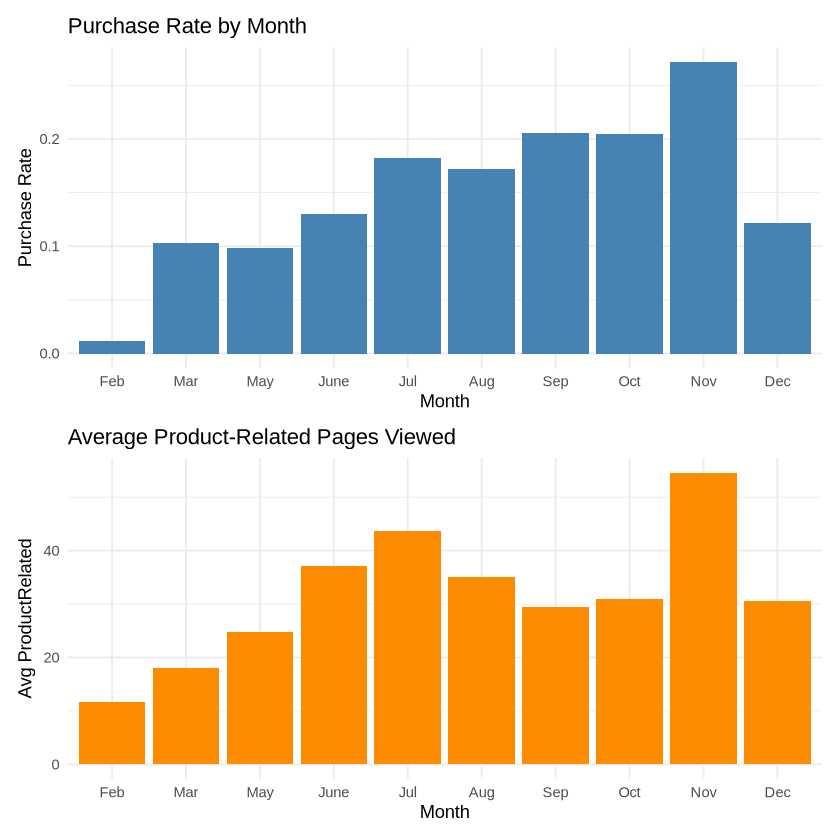

In [5]:
library(patchwork)

# Calculate monthly purchase rate
monthly_purchase <- shop_sub %>%
  group_by(Month) %>%
  summarise(purchase_rate = mean(Revenue == "Purchase"))

# Calculate monthly average engagement
monthly_engagement <- shop_sub %>%
  group_by(Month) %>%
  summarise(avg_product_related = mean(ProductRelated, na.rm = TRUE))

# Plot 1A: Purchase rate by month
p1 <- ggplot(monthly_purchase, aes(x = Month, y = purchase_rate)) +
  geom_col(fill = "steelblue") +
  labs(title = "Purchase Rate by Month",
       x = "Month",
       y = "Purchase Rate") +
  theme_minimal()

# Plot 1B: Avg product-related pages by month
p2 <- ggplot(monthly_engagement, aes(x = Month, y = avg_product_related)) +
  geom_col(fill = "darkorange") +
  labs(title = "Average Product-Related Pages Viewed",
       x = "Month",
       y = "Avg ProductRelated") +
  theme_minimal()

# Combine using patchwork
p1 / p2


#### Interpretation

The purchase rate shows a clear seasonal pattern, with noticeably higher rates from July through November and a peak in November. A similar upward trend appears in the average number of product-related pages viewed, suggesting that periods of increased engagement tend to coincide with periods of higher purchasing activity. Although the two metrics are not perfectly aligned month-to-month, both show elevated values during mid- to late-year months, indicating that users in these months generally explore more product pages and are more likely to complete purchases. This pattern supports the idea that deeper on-site engagement is associated with higher purchase likelihood, especially during the later months of the year.
    
Potential Issues: Since January and April are missing from the dat set, it may affect modelling with Month as a predictor. Engagement and purchase rates also vary substantially across months, suggesting potential heterogeneity that may require interaction terms or careful interpretation in regression.

## VISUAL 2 — Bounce vs Exit Rates by Purchase Outcome (From Aditya Bakshi's stage 2 report)

 Goal: Explore how user drop-off behaviour (bounce and exit rates) differs between purchase and non-purchase sessions across different months. 


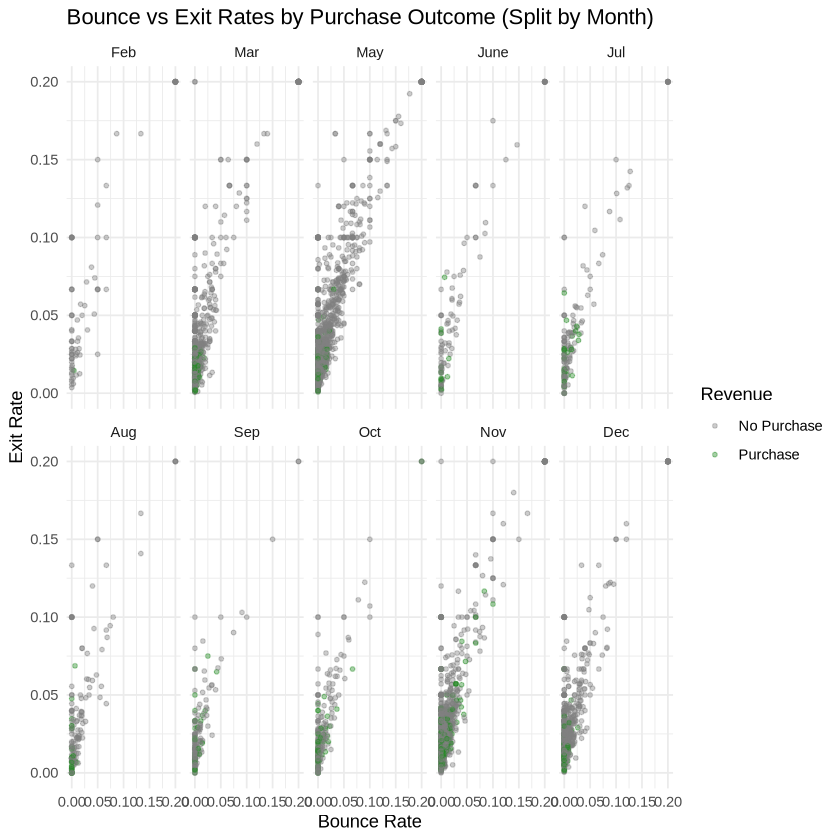

In [6]:
p3 <- ggplot(shop_sub, aes(x = BounceRates, y = ExitRates, color = Revenue)) +
  geom_point(alpha = 0.4, size = 1) +
  facet_wrap(~ Month, ncol = 5) +
  scale_color_manual(values = c("No Purchase" = "grey50",
                                "Purchase" = "forestgreen")) +
  labs(title = "Bounce vs Exit Rates by Purchase Outcome (Split by Month)",
       x = "Bounce Rate",
       y = "Exit Rate",
       color = "Revenue") +
  theme_minimal()

p3


#### Interpretation:

Across all months, sessions that result in purchases tend to have noticeably lower bounce and exit rates compared to sessions without purchases. The faceted panels show a consistent pattern: purchased sessions form dense clusters near the bottom-left corner, indicating minimal drop-off and deeper site engagement, while non-purchased sessions appear more spread out with higher rates of immediate exit. Although the exact distribution varies slightly month-to-month, the overall separation between the two outcome groups remains stable throughout the year. This suggests a clear association between reduced drop-off behaviour and higher purchase likelihood, reinforcing the idea that sessions with more sustained engagement are more likely to convert.

Potential Issues: The panels reveal several potential modelling concerns. BounceRates and ExitRates are strongly right-skewed, with most observations concentrated near zero, suggesting nonlinear relationships that may affect logistic model fit. A small number of sessions display unusually high bounce or exit values, serving as potential outliers. Additionally, the visible clustering of points indicates a moderate positive association between BounceRates and ExitRates, raising the possibility of multicollinearity when both variables are included in the model.

## Methods: Plan


### Overall modelling framework

The analysis uses logistic regression to model a binary response indicating whether a session ended with a purchase, reflecting that the outcome variable Revenue is coded as a two-level factor (No Purchase vs Purchase) after data cleaning. Logistic regression is appropriate because it directly models the log-odds of purchase as a function of engagement and temporal predictors, allows interpretation of coefficients as changes in odds, and aligns with the primary goal of making inferences about associations rather than building a purely predictive model. The modelling plan incorporates diagnostics and variable selection to arrive at a statistically valid and interpretable final model.

### Selection–Inference split

All modelling is performed on the Region 1 subset of the dataset, which contains 4,780 user sessions.
To ensure valid inference after variable selection, the dataset will be randomly split into:

- Selection set (60%): used exclusively for checking multicollinearity and performing variable selection.

- Inference set (40%): used exclusively to fit the final model and obtain valid coefficient estimates, standard errors, p-values, and odds ratios.

This prevents inflated significance that results from performing selection and inference on the same data.
Categorical variables (e.g., Month, Weekend, VisitorType, Revenue) are encoded as factors so that logistic regression correctly handles indicator variables.

### Multicollinearity assessment

A full logistic regression model will be fit on the selection set to assess multicollinearity.
We will use the GVIF^(1/(2·Df)) measure and compare it with the standard threshold √5.
Predictors exhibiting excessive multicollinearity will be removed before variable selection, and the full model will be refit accordingly.

### Variable Selection and Final Model Choice

After addressing multicollinearity, we will apply backward AIC selection on the selection set. This procedure begins with the reduced full model and iteratively removes predictors whose exclusion yields the largest improvement (or smallest increase) in AIC. Backward selection is appropriate because the sample size is large relative to the number of predictors, allowing the full model to be estimated stably and avoiding the sensitivity of forward procedures that start from an under-specified null model.

The resulting model formula will define the final model specification.
This model will then be refit on the inference set using logistic regression to obtain valid coefficient estimates, standard errors, p-values, and odds ratios.

### Model Assessment and Interpretation

We will evaluate:

- coefficient significance at α = 0.05

- odds ratios for interpretability

- direction and magnitude of associations

- model adequacy using AIC

Interpretation will focus on the strength and direction of associations with purchase likelihood.

## Code and Results

In [7]:
#load the package
library(tidymodels)
library(readr)
library(utils)
library(MASS)
library(car)
library(dplyr)

── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──

✔ dials        1.2.1     ✔ tune         1.2.1
✔ modeldata    1.4.0     ✔ workflows    1.1.4
✔ parsnip      1.2.1     ✔ workflowsets 1.1.0
✔ recipes      1.1.0     ✔ yardstick    1.3.1
✔ rsample      1.2.1     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Use suppressPackageStartupMessages() to eliminate package startup messages


Attaching package: ‘MASS’


The following object is masked from ‘package:patchwork’:

    area


The following object is masked from ‘package:dplyr’:

    select


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The fo

In [8]:
# Split the data into selection (60%) and inference (40%) sets
set.seed(123)
data_split <- initial_split(shop_sub, prop = 0.6, strata = Revenue)

selection_data <- training(data_split) 

inference_data <- testing(data_split)  



In [9]:
#examine the distribution of the response variable across categorical predictors in the inference dataset

table(inference_data$VisitorType)
table(inference_data$Month)
with(inference_data, table(Month, Revenue))



      New_Visitor             Other Returning_Visitor 
              267                 3              1643 


 Feb  Mar  May June  Jul  Aug  Sep  Oct  Nov  Dec 
  30  328  463   40   55   66   60   93  526  252 

      Revenue
Month  No Purchase Purchase
  Feb           30        0
  Mar          293       35
  May          427       36
  June          35        5
  Jul           48        7
  Aug           48       18
  Sep           49       11
  Oct           77       16
  Nov          372      154
  Dec          225       27

Before fitting the logistic regression model, the distribution of the response variable across categorical predictors was examined in the inference dataset. This revealed two issues that would prevent the model from producing stable and interpretable coefficient estimates.

- First, the VisitorType category “Other” appeared only three times in the inference data. Logistic regression cannot reliably estimate parameters for categories with such low representation, as extremely small group sizes often lead to unstable estimates and inflated standard errors.

- Second, the Month variable showed that February contained no purchase cases. All thirty observations from February were labeled “No Purchase,” creating a situation known as complete separation, where a predictor perfectly distinguishes between outcome classes. Logistic regression cannot estimate finite coefficients under complete separation, and this resulted in very large coefficient estimates and standard errors for the month indicators.


In [10]:
#Dropping "Other" from VisitorType and "Feb" from Month

selection_data <- selection_data |> filter(VisitorType != "Other") |> droplevels()
inference_data <- inference_data |> filter(VisitorType != "Other") |> droplevels()

selection_data  <- selection_data  %>% filter(Month != "Feb") %>% droplevels()
inference_data  <- inference_data  %>% filter(Month != "Feb") %>% droplevels()


Before performing variable selection, we first evaluate multicollinearity on the selection set.

In [11]:
# Fit a full logistic regression model on the selection set
mod_select_full<- glm(Revenue ~ ., data = selection_data, family = "binomial")

# and assess multicollinearity using GVIF-based diagnostics.
vif(mod_select_full)

,GVIF,Df,GVIF^(1/(2*Df))
Administrative,1.786946,1,1.336767
Administrative_Duration,2.418492,1,1.555150
Informational,1.868299,1,1.366857
Informational_Duration,2.093931,1,1.447042
ProductRelated,4.942232,1,2.223113
ProductRelated_Duration,6.177779,1,2.485514
BounceRates,1.894550,1,1.376427
ExitRates,2.045849,1,1.430332
PageValues,1.088371,1,1.043250
SpecialDay,1.349376,1,1.161627


**Table 1. GVIF Multicollinearity Diagnostics (Selection Set)**  
We compare the adjusted GVIF measures to the common threshold √5 ≈ 2.24. Only `ProductRelated_Duration` shows moderate multicollinearity (GVIF^(1/(2·Df)) ≈ 2.47), so we remove it before proceeding with model selection.

In [12]:
# Remove ProductRelated_Duration from both datasets to ensure 
# it is excluded from all subsequent models.
selection_data <- selection_data |>
    dplyr::select(-ProductRelated_Duration)

inference_data <- inference_data |>
    dplyr::select(-ProductRelated_Duration)

# Refit the full model without ProductRelated_Duration
mod_select_full2 <- glm(Revenue ~ ., 
                 data = selection_data, 
                 family = "binomial")

# Recheck for multicollinearity using VIF again (removed)
vif(mod_select_full2)

,GVIF,Df,GVIF^(1/(2*Df))
Administrative,1.710395,1,1.307821
Administrative_Duration,1.690921,1,1.300354
Informational,1.893841,1,1.376169
Informational_Duration,1.873833,1,1.368880
ProductRelated,1.688765,1,1.299525
BounceRates,1.876238,1,1.369759
ExitRates,2.017806,1,1.420495
PageValues,1.087816,1,1.042984
SpecialDay,1.349680,1,1.161757
Month,1.629139,8,1.030973


**Table 2. GVIF Diagnostics After Removing ProductRelated_Duration**

After excluding `ProductRelated_Duration`, all remaining predictors have GVIF^(1/(2·Df)) < √5, indicating that multicollinearity is no longer a major concern.

After confirming that multicollinearity is at an acceptable level, we perform backward AIC selection on the selection set. Backward selection begins from the reduced full model and iteratively removes predictors that do not meaningfully improve AIC.

In [2]:
# Perform backward AIC selection using the selection set
# From Hao Chang's stage 2 report
mod_select <- stepAIC(mod_select_full2, direction = "backward")

ERROR: Error in stepAIC(mod_select_full2, direction = "backward"): could not find function "stepAIC"


The final selected model includes the following predictors:
Administrative, Informational, ProductRelated, ExitRates, PageValues, Month and VisitorType.
    
The model structure obtained from backward AIC selection is then refit on the inference set to obtain valid coefficient estimates, standard errors, and p-values. This final model is used for all interpretation, since no variable selection is performed on the inference data.

In [14]:
# Extract the final model formula selected through backward AIC
final_formula <- formula(mod_select)

# Refit the model on the inference set to obtain valid inferential estimates
mod_inference <- glm(
   final_formula,
   data = inference_data,
   family = "binomial"
 )

# Summarize the final model used for statistical inference
summary(mod_inference)


Call:
glm(formula = final_formula, family = "binomial", data = inference_data)

Coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                   -2.105428   0.287756  -7.317 2.54e-13 ***
Administrative                 0.012476   0.023934   0.521 0.602189    
Informational                  0.025398   0.056720   0.448 0.654311    
ProductRelated                 0.005190   0.001587   3.270 0.001076 ** 
ExitRates                    -15.971298   4.282279  -3.730 0.000192 ***
PageValues                     0.080630   0.005998  13.443  < 2e-16 ***
MonthMay                      -0.605281   0.319077  -1.897 0.057831 .  
MonthJune                      0.195789   0.642285   0.305 0.760494    
MonthJul                       0.188855   0.525224   0.360 0.719168    
MonthAug                       1.011396   0.411830   2.456 0.014055 *  
MonthSep                       0.549263   0.456847   1.202 0.229251    
MonthOct                       0.155599  

**Table 3. Final Logistic Regression Model Fitted on the Inference Set**  
Table 3 reports coefficient estimates, standard errors, z-values, and p-values for the final model fitted on the inference set. Because variable selection was carried out on a separate selection set, these p-values and confidence intervals are more reliable for inference.

To aid interpretation, we convert the logistic regression coefficients into odds ratios (OR = exp(estimate)).

In [15]:
# Convert log-odds coefficients to odds ratios for interpretation
odds_ratios <- exp(coef(mod_inference))
odds_ratios

(Intercept)               Administrative 
                1.217936e-01                 1.012554e+00 
               Informational               ProductRelated 
                1.025723e+00                 1.005204e+00 
                   ExitRates                   PageValues 
                1.158120e-07                 1.083970e+00 
                    MonthMay                    MonthJune 
                5.459208e-01                 1.216271e+00 
                    MonthJul                     MonthAug 
                1.207866e+00                 2.749437e+00 
                    MonthSep                     MonthOct 
                1.731976e+00                 1.168358e+00 
                    MonthNov                     MonthDec 
                3.490322e+00                 7.921748e-01 
VisitorTypeReturning_Visitor 
                5.931743e-01

## Interpretation

We use a **significance level of α = 0.05** when interpreting statistical significance.

#### Key Predictors

- ProductRelated (OR = 1.0052, p = 0.001)

A one-unit increase in ProductRelated is estimated to be associated with a 0.5% increase in purchase odds, holding all else constant.


- PageValues (OR = 1.0839, p < 0.001)

Each additional unit in PageValues is associated with an estimated 8.4% increase in purchase odds, holding other predictors constant.

- ExitRates (OR ≈ 1.16 × 10^(-7),p < 0.001)

Because ExitRates ranges between 0 and 1, its OR magnitude is not directly meaningful, so it is interpreted directionally: higher ExitRates are associated with lower purchase odds, holding other variables constant.

- VisitorTypeReturning_Visitor (OR = 0.593, p = 0.015)

Returning visitors are estimated to have 41% lower purchase odds relative to new visitors, holding other predictors constant.

All month coefficients are interpreted relative to March, the baseline category.

- MonthAug (OR = 2.75, p = 0.014)
  
Sessions occurring in August are estimated to have 2.75 times higher purchase odds than March, holding all else constant.

- MonthNov (OR = 3.49, p < 0.001)
  
Sessions in November are associated with 3.49 times higher purchase odds relative to March, holding other predictors constant.

#### Non-significant predictors

Administrative, Informational, and several month indicators (e.g., May, June, September, October, December) do not show statistical evidence of association with purchase odds at the 5% level.
Their odds ratios should therefore be interpreted with caution.

### Comparison Between Models

Our modelling workflow used three models, each with a distinct purpose:

1. Full Models (Diagnostics Only)

The full logistic regression models—before and after removing `ProductRelated_Duration` were used only to check multicollinearity via GVIF.
They helped identify unstable predictors but were not used for variable selection or inference.

2. Selection Model (Backward AIC on the Selection Set)

Backward AIC selection was applied to the selection set to determine the final model structure. It starts from the reduced full model and iteratively removes predictors that do not meaningfully contribute to AIC.
Because this step uses the data for variable selection, the resulting coefficients are not suitable for inference.
Its sole purpose is to identify a parsimonious set of predictors.

3. Inference Model (Refit on the Inference Set)

The selected model was then refit on the inference set, which was not used during selection.

This provides unbiased coefficient estimates and valid standard errors and p-values because no selection occurred on this dataset.
This is the only model used for interpretation in the report.

In summary, full models diagnose multicollinearity; the selection model identifies the predictor set; the inference model provides valid statistical conclusions.

# Section 4 : Discussion

The goal of this analysis was to examine how user engagement behaviours and temporal patterns are associated with the likelihood of generating revenue among Region 1 user sessions. Using logistic regression with careful variable selection and diagnostic checks, we identified several meaningful behavioural and contextual predictors of purchase likelihood.

#### Summary of Findings and Implications

Our results indicate that both engagement-related behaviours and temporal characteristics play important roles in explaining purchase outcomes. Higher PageValues and increased counts of ProductRelated page visits are associated with higher odds of purchase, suggesting that sessions involving deeper product exploration and higher expected revenue per page tend to convert more frequently. Conversely, ExitRates show a strong negative association with purchase likelihood, reinforcing the idea that early disengagement or abrupt drop-off is incompatible with successful conversion.

Temporal variables also demonstrated notable effects. Several months, like  December, March, and May, were associated with significantly lower purchase odds relative to August, even after controlling for behavioural engagement. This suggests potential seasonal or context-specific patterns in purchasing behaviour that may reflect broader trends in user interest, promotional cycles, or consumer intent during different parts of the year.

Together, these findings highlight that conversions occur when users remain engaged, view product-related content, and avoid quick exits—patterns consistent with common digital commerce insights and what we expected based on prior literature on online shopping behaviour.

#### Alignment With Expectations

These results were largely expected, as prior research has shown a clear correlation between user interaction and purchase behaviour; studies such as Sismeiro & Bucklin (2004) and Moe (2003) similarly find that deeper engagement with product pages is associated with higher conversion likelihood.

#### Model Limitations and Opportunities for Improvement

Although the final logistic regression model provides useful insights, several limitations should be noted:

* **Restricted geographic scope**: The analysis focuses only on Region 1 sessions, which limits generalizability to other regions.

* **Observational data**: Because the data were not collected through a controlled experiment, all associations are correlational and cannot be interpreted causally.

* **Missing calendar months**: The absence of January and April, and removal of February, reduces temporal completeness and may introduce bias into month comparisons.

* **Potential nonlinear effects**: Some engagement variables (e.g., BounceRates, ExitRates) exhibit strong right-skewness and may benefit from alternative modelling approaches such as transformations, splines, or non-linear methods.

* **Interaction effects not explored**: Behavioural interactions (e.g., between PageValues and ProductRelated activity) may meaningfully improve interpretability and predictive ability but were not included to maintain model simplicity.

Future models could address these limitations by experimenting with additional predictors, interaction terms, or more flexible modelling techniques such as generalized additive models (GAMs) or tree-based approaches.

#### Future Research Directions

Several extensions follow naturally from this study:

* Investigating seasonal or event-driven factors in greater detail (e.g., holidays, promotions, or day-of-week effects).

* Exploring behavioural interaction effects to understand how combinations of engagement metrics jointly influence purchase likelihood.

* Expanding the analysis to include other regions or demographic subsets to compare behavioural patterns across user groups.

* Evaluating predictive performance using additional machine learning approaches, which may capture nonlinear engagement effects more effectively.

* Studying long-term user behaviour, such as repeated visits or customer lifetime value, which may provide richer insight into purchasing intent.

# Section 5 : References

Sismeiro & Bucklin (2004)
Sismeiro, C., & Bucklin, R. E. (2004). Modeling purchase behavior at an e-commerce Web site: A task-completion approach. Management Science, 50(3), 362–379.

Moe (2003)
Moe, W. W. (2003). Buying, searching, or browsing: Differentiating between online shoppers using in-store tracking data. Journal of Consumer Psychology, 13(1–2), 29–39.

Li, Wang, & Zhang (2020)
Li, H., Wang, J., & Zhang, J. (2020). Determinants of online shopping behavior using clickstream data. Electronic Commerce Research, 20(1), 67–88.